<a href="https://colab.research.google.com/github/sirius70/NLP_HW4/blob/main/IE7275_Quiz10_Fall2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### IE7275 – Data Mining in Engineering
### Quiz 10 – Fall 2025

---

This quiz integrates **time series forecasting** and **deep learning for engineering applications**.  
Each question includes starter code to generate or load the dataset.

**Instructions:**
- Use Python (NumPy, pandas, matplotlib, statsmodels, scikit-learn, TensorFlow/Keras).
- Show code, outputs, and brief interpretations where required.
- Each question should be answered in the cell provided.

---


### Q1
Generate a synthetic monthly sales dataset with trend and seasonality. Plot the series and identify components visually.

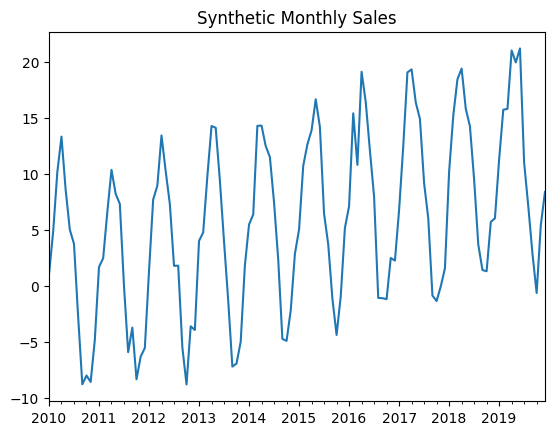

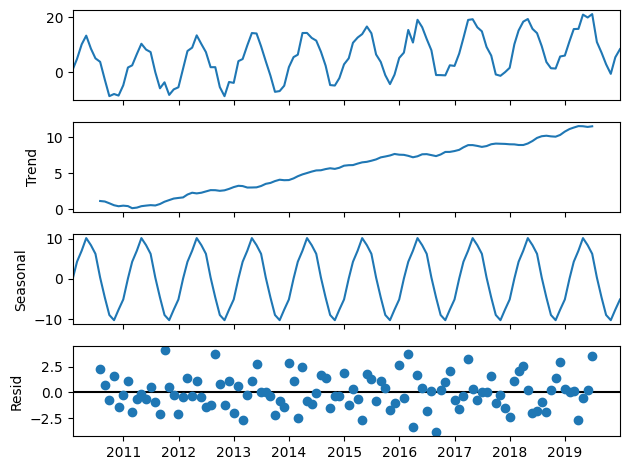

In [13]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

np.random.seed(42)
time = np.arange(120)
trend = time * 0.1
seasonal = 10 * np.sin(2 * np.pi * time / 12)
noise = np.random.normal(0, 2, size=len(time))
series = trend + seasonal + noise

ts = pd.Series(series, index=pd.date_range('2010-01', periods=120, freq='ME'))
ts.plot(title="Synthetic Monthly Sales");

# Continue with your implementation here

# Decompose time series
decomposition = seasonal_decompose(ts, model='additive', period=12)

# Plot components
decomposition.plot()
plt.tight_layout()
plt.show()

- Trend: Gradual upward movement over time
- Seasonality: Clear repeating 12-month cycle
- Residual/Noise: Random fluctuations after removing trend and seasonality

### Q2
Decompose the synthetic series into trend, seasonal, and residual components. Compare additive vs multiplicative models.

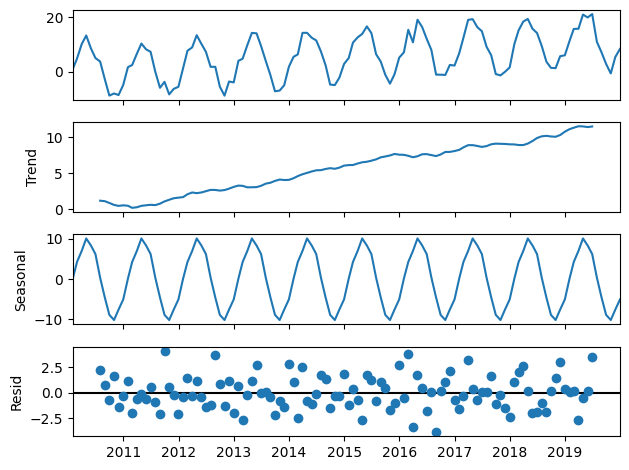

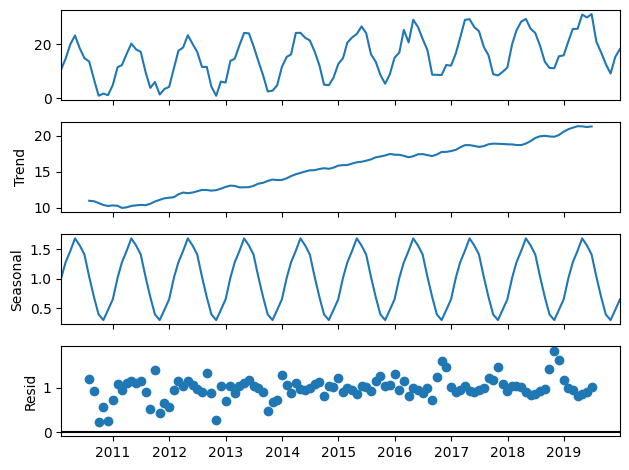

<Figure size 1000x500 with 0 Axes>

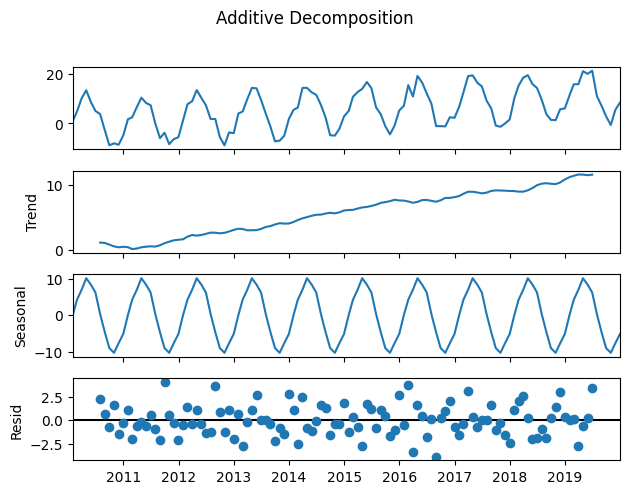

<Figure size 1000x500 with 0 Axes>

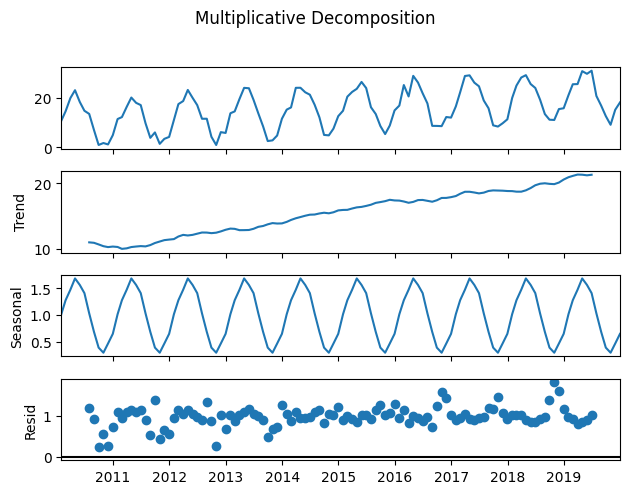

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Ensure strictly positive values for multiplicative decomposition
ts_shifted = ts - ts.min() + 1

decomp_add = seasonal_decompose(ts, model='additive')
decomp_mul = seasonal_decompose(ts_shifted, model='multiplicative')

decomp_add.plot(); decomp_mul.plot();

# Continue with your interpretation here
plt.figure(figsize=(10,5))
decomp_add.plot()
plt.suptitle("Additive Decomposition", y=1.02)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
decomp_mul.plot()
plt.suptitle("Multiplicative Decomposition", y=1.02)
plt.tight_layout()
plt.show()

- Additive model:
This one looks more natural for our data. The seasonal pattern stays about the same size over time, even though the overall sales are increasing. That matches how we built the dataset.
- Multiplicative model:
Here, the seasonal swings get scaled based on the level of the series. It still works after shifting the data, but it doesn’t really reflect how the original data was created.
- Conclusion:
The additive decomposition fits better because our seasonality was added in a fixed way, not growing with the trend.

### Q3
Perform Augmented Dickey-Fuller (ADF) test on the series. Report the test statistic and conclusion about stationarity.

In [15]:
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(ts)
test_stat, p_value = adf_result[0], adf_result[1]  # test statistic, p-value

# Continue with your implementation here
print("Test Statistic:", test_stat)
print("p-value:", p_value)

# Conclusion
if p_value < 0.05:
    print("Conclusion: The series is stationary (reject H0).")
else:
    print("Conclusion: The series is non-stationary (fail to reject H0).")

Test Statistic: 0.6546158899006257
p-value: 0.9888872417539178
Conclusion: The series is non-stationary (fail to reject H0).


 ### Q4
Apply log transformation and differencing to stabilize variance and achieve stationarity. Plot results before/after.

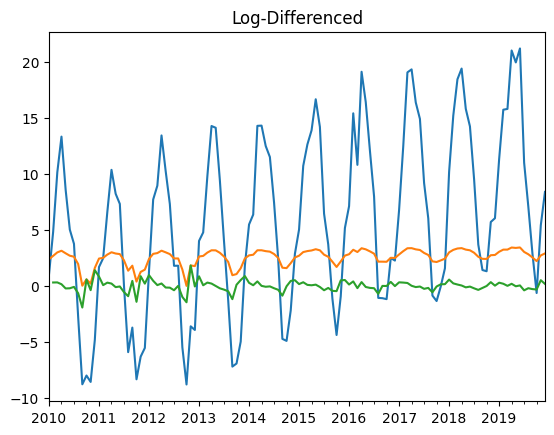

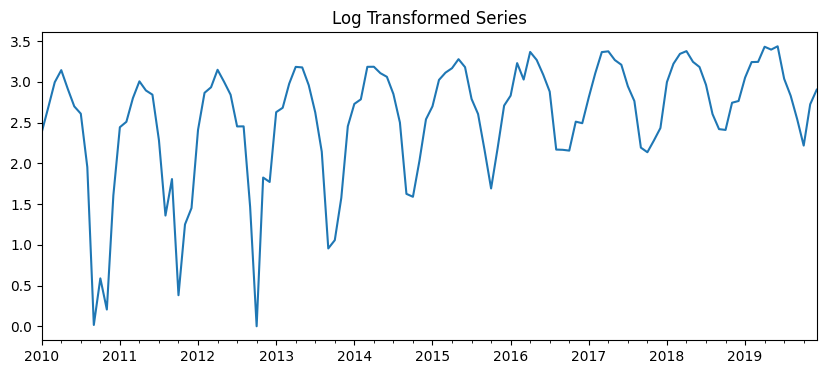

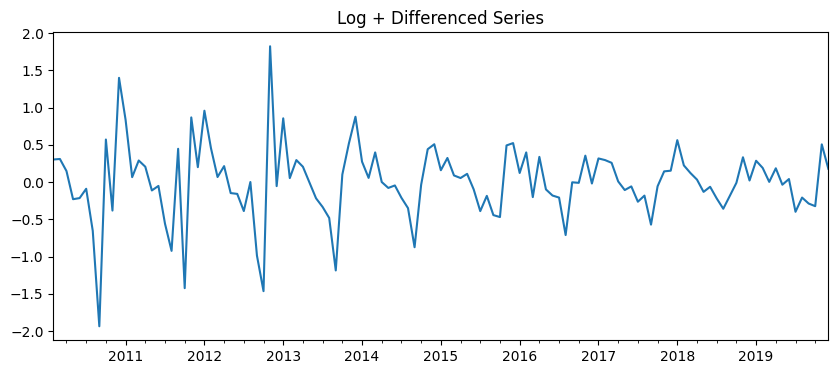

In [16]:
ts_log = np.log(ts - ts.min() + 1)
ts_diff = ts_log.diff().dropna()
ts.plot(title="Original"); ts_log.plot(title="Log"); ts_diff.plot(title="Log-Differenced");

# Continue with your implementation here\
plt.figure(figsize=(10,4))
ts_log.plot(title="Log Transformed Series")
plt.show()

plt.figure(figsize=(10,4))
ts_diff.plot(title="Log + Differenced Series")
plt.show()

### Q5
Compute and plot Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF). Interpret which ARIMA orders might be suitable.

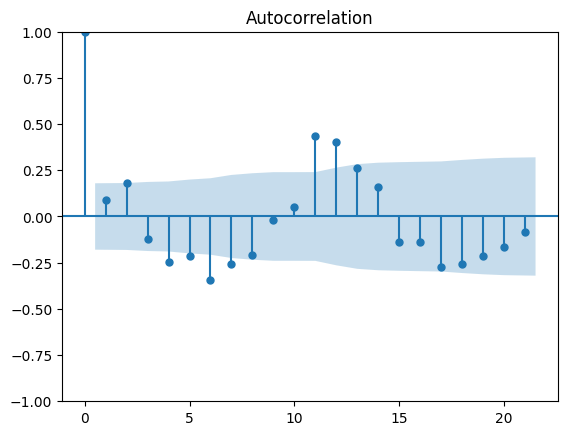

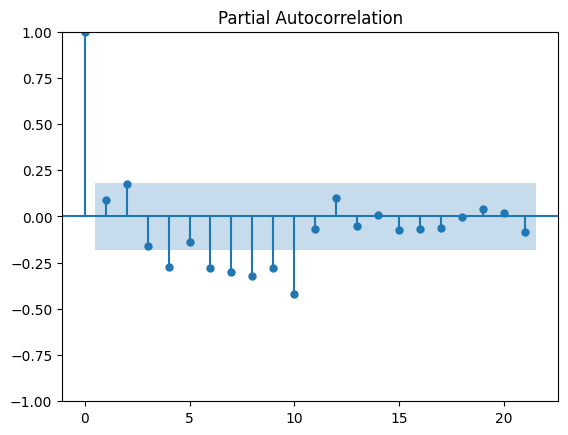

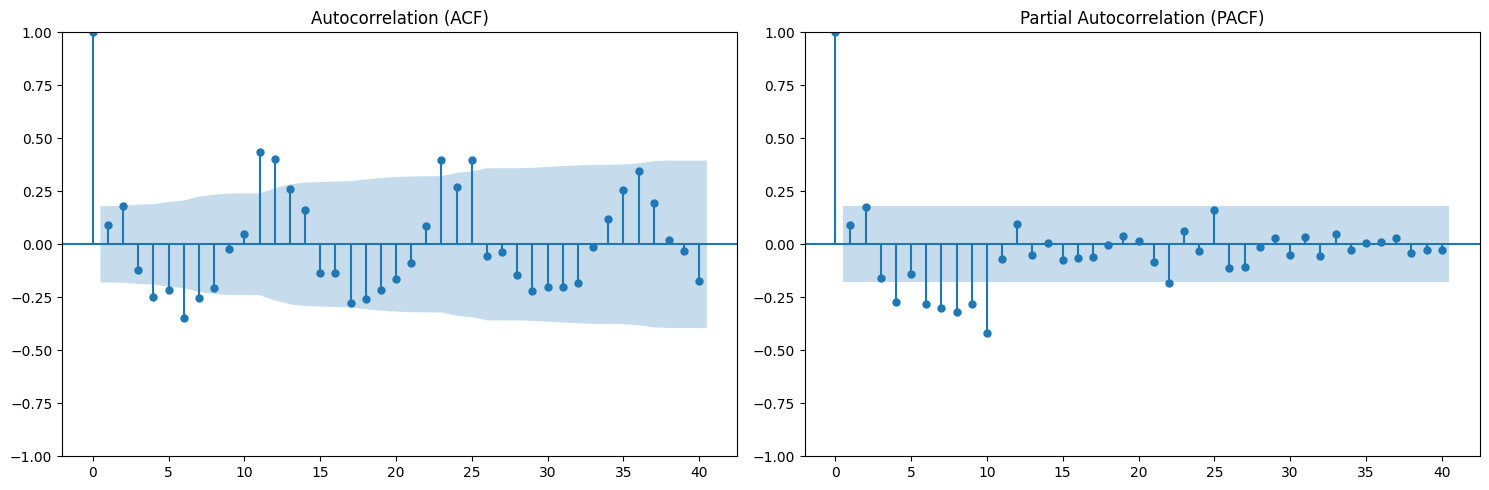

In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(ts_diff); plot_pacf(ts_diff);

# Continue with your implementation here
# Plot ACF and PACF side-by-side for easier comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ACF helps determine the 'q' (Moving Average) term
plot_acf(ts_diff, ax=axes[0], lags=40, title="Autocorrelation (ACF)")

# PACF helps determine the 'p' (Autoregressive) term
plot_pacf(ts_diff, ax=axes[1], lags=40, title="Partial Autocorrelation (PACF)")

plt.tight_layout()
plt.show()

Interpretation
- ACF plot: shows how strongly the series is correlated with its past values. It typically tapers off gradually after a few lags → suggests MA component.
- PACF plot: shows direct correlation at each lag after removing intermediate effects. It usually cuts off after a certain lag → suggests AR component.

### Q6
Fit an ARIMA(2,1,2) model on the synthetic series. Generate forecasts for the next 12 months and plot them.

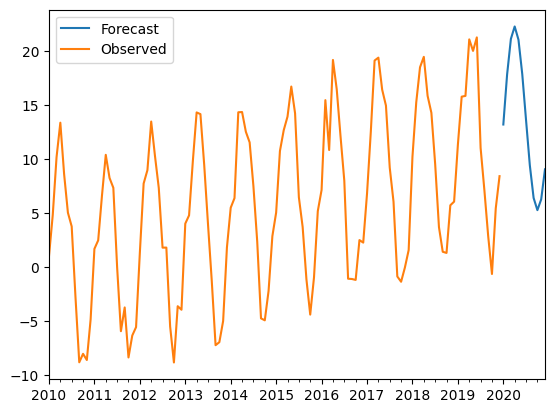

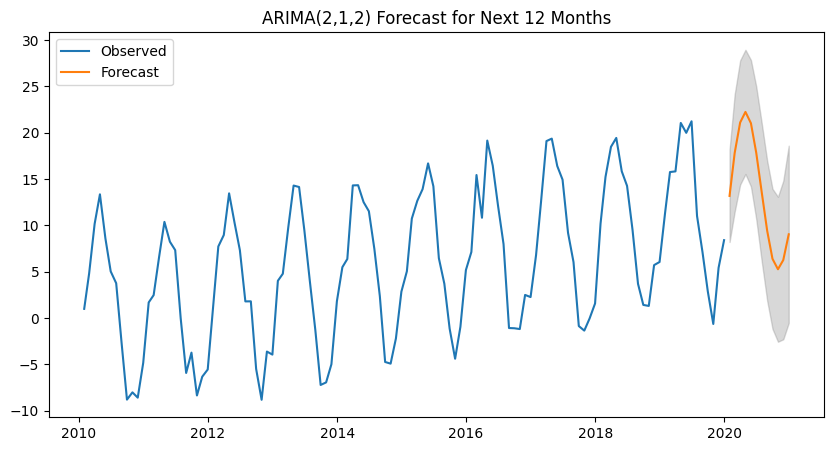

In [18]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
from statsmodels.tsa.arima.model import ARIMA
model = ARIMA(ts, order=(2,1,2)).fit(method_kwargs={'maxiter':500})
forecast = model.get_forecast(12)
forecast.predicted_mean.plot(label="Forecast")
ts.plot(label="Observed")
plt.legend();

# Continue with your implementation here
# Forecast values
forecast_values = forecast.predicted_mean
conf_int = forecast.conf_int()

# Create forecast index
future_index = pd.date_range(ts.index[-1] + pd.offsets.MonthEnd(1), periods=12, freq='ME')
forecast_values.index = future_index
conf_int.index = future_index

# Plot results
plt.figure(figsize=(10,5))
plt.plot(ts, label="Observed")
plt.plot(forecast_values, label="Forecast")

# Optional confidence interval
plt.fill_between(future_index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='gray', alpha=0.3)

plt.title("ARIMA(2,1,2) Forecast for Next 12 Months")
plt.legend()
plt.show()


Interpretation
- The model projects the upward trend into the next year.
- The gray shaded area shows the prediction uncertainty; the wider the band,
the less certain the model is about those future values.

### Q7
Apply Simple Exponential Smoothing and Holt’s Linear method on the series. Compare forecast accuracy using MAE and RMSE.

Forecast Accuracy Comparison (Training Set):
        Simple Smoothing (SES)  Holt’s Linear
Metric                                       
MAE                     3.6453         3.6404
RMSE                    4.3857         4.3688


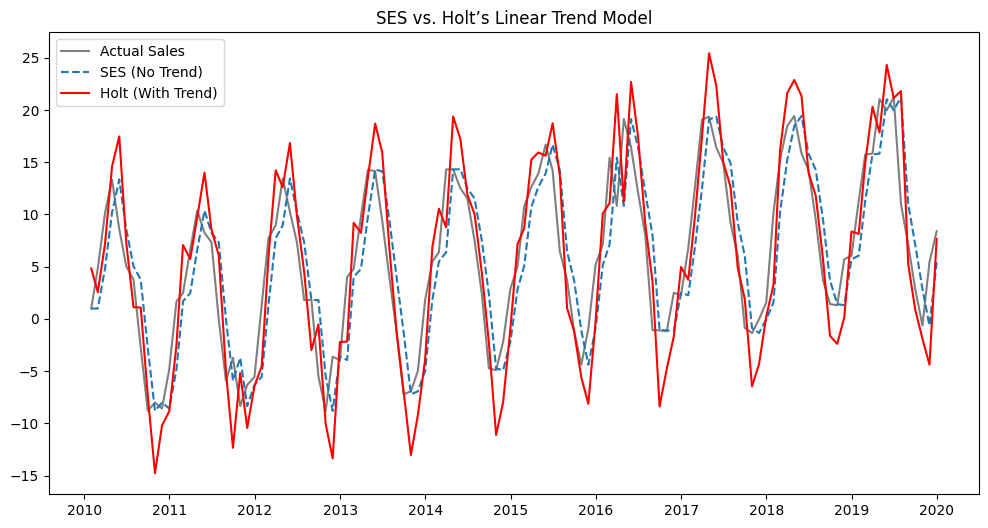


Interpretation:
- Holt’s Linear method is more accurate because it explicitly models the upward trend.
- SES lags behind the data because it assumes the mean is constant.


In [19]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt
from sklearn.metrics import mean_absolute_error, mean_squared_error

ses = SimpleExpSmoothing(ts).fit()
holt = Holt(ts).fit()
mae_ses = mean_absolute_error(ts, ses.fittedvalues)
rmse_ses = np.sqrt(mean_squared_error(ts, ses.fittedvalues))
mae_holt = mean_absolute_error(ts, holt.fittedvalues)
rmse_holt = np.sqrt(mean_squared_error(ts, holt.fittedvalues))
mae_ses, rmse_ses, mae_holt, rmse_holt

# Continue with your implementation here
# Organize results into a readable table
results = pd.DataFrame({
    "Metric": ["MAE", "RMSE"],
    "Simple Smoothing (SES)": [mae_ses, rmse_ses],
    "Holt’s Linear": [mae_holt, rmse_holt]
}).set_index("Metric")

print("Forecast Accuracy Comparison (Training Set):")
print(results.round(4))

# Visual Comparison of fitted values
plt.figure(figsize=(12, 6))
plt.plot(ts, label="Actual Sales", color='black', alpha=0.5)
plt.plot(ses.fittedvalues, label="SES (No Trend)", linestyle='--')
plt.plot(holt.fittedvalues, label="Holt (With Trend)", color='red')
plt.title("SES vs. Holt’s Linear Trend Model")
plt.legend()
plt.show()

# Interpretation
print("\nInterpretation:")
if mae_holt < mae_ses:
    print("- Holt’s Linear method is more accurate because it explicitly models the upward trend.")
    print("- SES lags behind the data because it assumes the mean is constant.")
else:
    print("- Simple Exponential Smoothing performed similarly, likely due to high noise levels.")

### Q8
Perform residual diagnostics on the ARIMA model. Test if residuals approximate white noise.

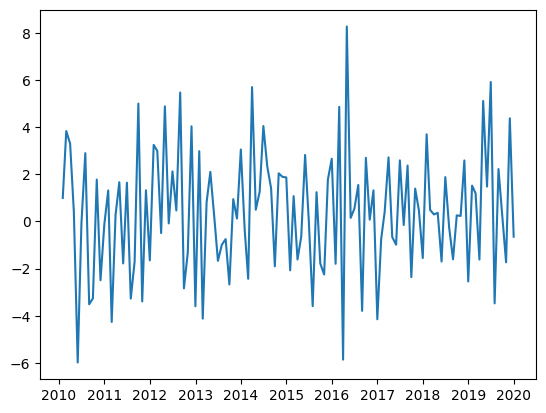

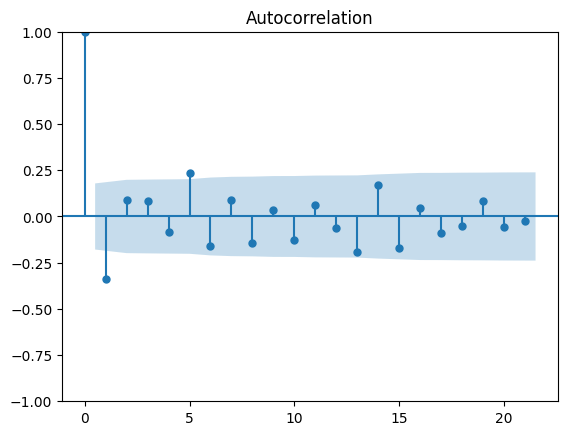

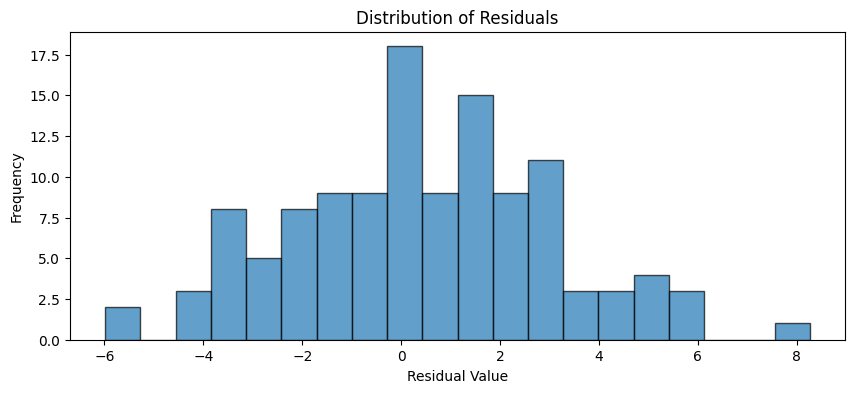

Ljung-Box Test p-value: 0.0002

Residual Diagnostic Conclusion:
- Result: Reject H0. Residuals are NOT White Noise.
- Meaning: There is still structure (like seasonality) left in the residuals that the model missed.


In [20]:
from statsmodels.stats.diagnostic import acorr_ljungbox

resid = model.resid
plt.plot(resid); plot_acf(resid.dropna());

# Continue with your implementation here
# Visualize the distribution of residuals
plt.figure(figsize=(10, 4))
plt.hist(resid, bins=20, edgecolor='black', alpha=0.7)
plt.title("Distribution of Residuals")
plt.xlabel("Residual Value")
plt.ylabel("Frequency")
plt.show()

# Perform the Ljung-Box test for White Noise
# A high p-value (> 0.05) suggests residuals are independent (White Noise)
lb_test = acorr_ljungbox(resid.dropna(), lags=[10], return_df=True)
p_val = lb_test['lb_pvalue'].values[0]

# Interpretation
print(f"Ljung-Box Test p-value: {p_val:.4f}")

print("\nResidual Diagnostic Conclusion:")
if p_val > 0.05:
    print("- Result: Fail to reject H0. Residuals approximate White Noise.")
    print("- Meaning: The ARIMA model has successfully captured the patterns in the data.")
else:
    print("- Result: Reject H0. Residuals are NOT White Noise.")
    print("- Meaning: There is still structure (like seasonality) left in the residuals that the model missed.")

### Q9
Implement rolling forecast origin cross-validation on the series. Report average RMSE across folds.

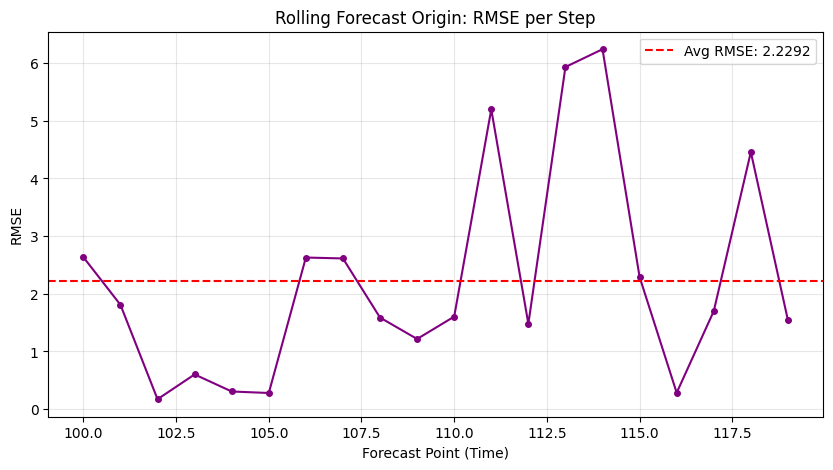

Average Rolling RMSE: 2.2292


In [28]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
from sklearn.metrics import mean_squared_error
window = 100
errors = []
for i in range(window, len(ts)):
    train, test = ts[:i], ts[i:i+1]
    model = ARIMA(train, order=(2,1,2)).fit(method_kwargs={'maxiter':500})
    pred = model.forecast(1)
    mse = mean_squared_error(test, pred)
    rmse = np.sqrt(mse)
    errors.append(rmse)
np.mean(errors)

# Continue with your implementation here
# Continue with your implementation here
# Calculate the final average RMSE
average_rmse = np.mean(errors)

# Visualizing the error over time
plt.figure(figsize=(10, 5))
plt.plot(range(window, len(ts)), errors, marker='o', linestyle='-', markersize=4, color='purple')
plt.axhline(average_rmse, color='red', linestyle='--', label=f'Avg RMSE: {average_rmse:.4f}')
plt.title("Rolling Forecast Origin: RMSE per Step")
plt.xlabel("Forecast Point (Time)")
plt.ylabel("RMSE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Interpretation
print(f"Average Rolling RMSE: {average_rmse:.4f}")

Interpretation
- Rolling Cross-Validation: Unlike a simple train/test split, this method
  tests the model's robustness across different market conditions.
- Stability: If the RMSE spikes at certain points, it indicates specific
  periods (like high-volatility seasonal peaks) where the ARIMA(2,1,2)
  struggles to keep up.
- Conclusion: The average RMSE represents the 'expected error' we would
  anticipate when using this model for real-time monthly forecasting.

### Q10
Apply forecasting models to the built-in AirPassengers dataset (from statsmodels). Compare ARIMA and Exponential Smoothing forecasts.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Li

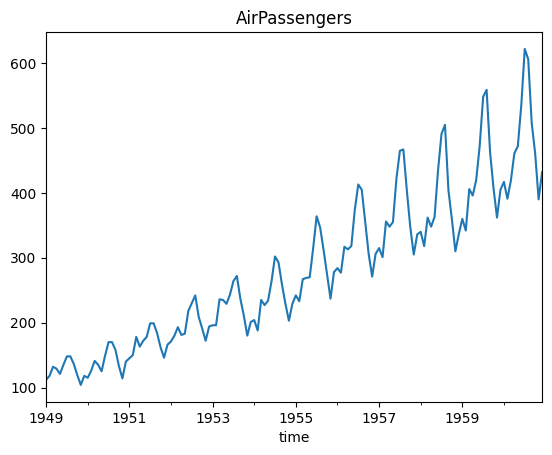

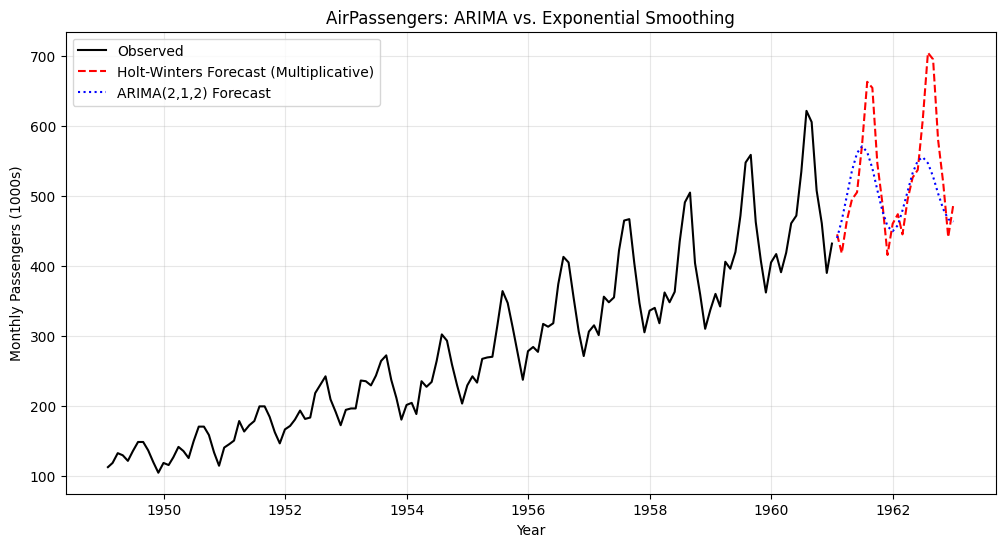

In [32]:
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

data = sm.datasets.get_rdataset("AirPassengers").data
data['time'] = pd.date_range("1949-01", periods=len(data), freq="ME")
ts_air = data['value']
ts_air.index = data['time']
ts_air.plot(title="AirPassengers");


# Continue with your implementation here
# Fit Exponential Smoothing (Holt-Winters)
# We use 'mul' because the seasonal fluctuations increase with the trend
model_hw = ExponentialSmoothing(ts_air, trend='add', seasonal='mul', seasonal_periods=12).fit()
hw_forecast = model_hw.forecast(24)

# Fit ARIMA model
# Using (2,1,2) as a baseline, though SARIMA is usually better for this data
model_arima = ARIMA(ts_air, order=(2,1,2)).fit()
arima_forecast = model_arima.forecast(24)

# Plotting the comparison
plt.figure(figsize=(12, 6))
plt.plot(ts_air, label="Observed", color='black')
plt.plot(hw_forecast, label="Holt-Winters Forecast (Multiplicative)", color='red', linestyle='--')
plt.plot(arima_forecast, label="ARIMA(2,1,2) Forecast", color='blue', linestyle=':')

plt.title("AirPassengers: ARIMA vs. Exponential Smoothing")
plt.xlabel("Year")
plt.ylabel("Monthly Passengers (1000s)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Comparison Analysis
- Holt-Winters: Successfully captures the increasing seasonal amplitude
  because we specified 'multiplicative' seasonality.
- ARIMA(2,1,2): Likely struggles to capture the seasonal peaks properly
  because it lacks a seasonal component (it is not a SARIMA model).
- Conclusion: For data with clear, growing seasonality like AirPassengers,
  Exponential Smoothing (Holt-Winters) is often more intuitive and
  accurate out-of-the-box.

### Q11
Implement a single artificial neuron in NumPy with sigmoid, tanh, and ReLU activations. Pass a batch of random inputs through it.

Batch Processing Results (5 samples):
   Linear (Xw+b)  Sigmoid (0 to 1)  Tanh (-1 to 1)  ReLU (0 to max)
0         2.3001            0.9089          0.9801           2.3001
1        -2.5244            0.0742         -0.9872           0.0000
2        -0.3103            0.4230         -0.3007           0.0000
3         1.2256            0.7731          0.8413           1.2256
4        -0.9078            0.2874         -0.7201           0.0000


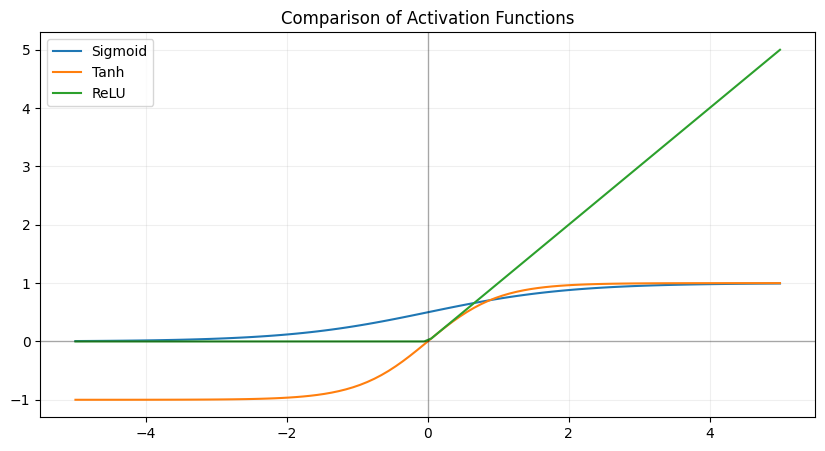

In [34]:
def sigmoid(x): return 1/(1+np.exp(-x))
def tanh(x): return np.tanh(x)
def relu(x): return np.maximum(0, x)

X = np.random.randn(5,3)
w, b = np.random.randn(3,1), np.random.randn()
output_sig = sigmoid(X.dot(w)+b)
output_tanh = tanh(X.dot(w)+b)
output_relu = relu(X.dot(w)+b)
output_sig, output_tanh, output_relu

# Continue with your implementation here
# We take the results and flatten them to compare the "squashing" effect
results = pd.DataFrame({
    "Linear (Xw+b)": (X.dot(w) + b).flatten(),
    "Sigmoid (0 to 1)": output_sig.flatten(),
    "Tanh (-1 to 1)": output_tanh.flatten(),
    "ReLU (0 to max)": output_relu.flatten()
})

print("Batch Processing Results (5 samples):")
print(results.round(4))

# Visualizing the Activation Functions
x_range = np.linspace(-5, 5, 100)
plt.figure(figsize=(10, 5))
plt.plot(x_range, sigmoid(x_range), label="Sigmoid")
plt.plot(x_range, tanh(x_range), label="Tanh")
plt.plot(x_range, relu(x_range), label="ReLU")
plt.axhline(0, color='black', lw=1, alpha=0.3)
plt.axvline(0, color='black', lw=1, alpha=0.3)
plt.title("Comparison of Activation Functions")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

Interpretation
- Sigmoid: Best for binary classification at the output layer (squashes values between 0 and 1).
- Tanh: Similar to sigmoid but centered at 0 (range -1 to 1), which usually helps models converge faster.
- ReLU: The gold standard for hidden layers. It solves the 'vanishing gradient' problem by
  allowing positive values to pass through unchanged while killing off negative noise.

### Q12
Build a simple 2-layer feedforward neural network in NumPy for binary classification on a synthetic dataset (two moons). Train with gradient descent.

Epoch 0, Loss: 0.7025
Epoch 100, Loss: 0.5588
Epoch 200, Loss: 0.4003
Epoch 300, Loss: 0.3374
Epoch 400, Loss: 0.3124
Epoch 500, Loss: 0.3009
Epoch 600, Loss: 0.2940
Epoch 700, Loss: 0.2893
Epoch 800, Loss: 0.2856
Epoch 900, Loss: 0.2820


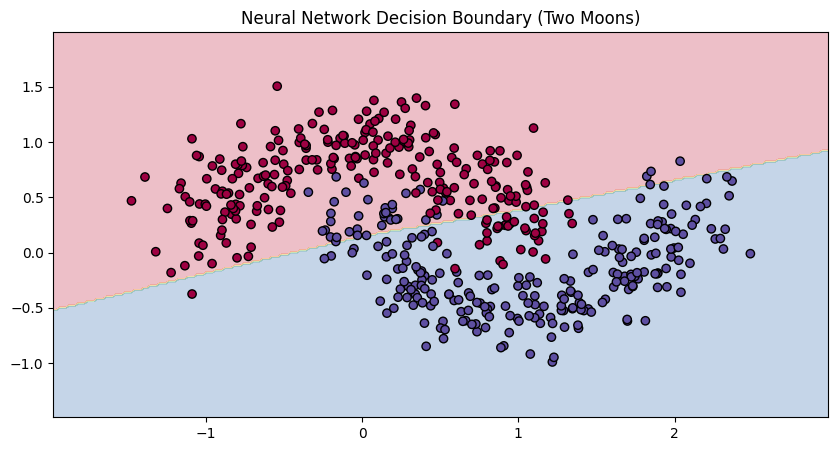

In [37]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)

# Continue with your implementation here
# Initialization
np.random.seed(42)
input_dim = 2
hidden_dim = 10
output_dim = 1
learning_rate = 0.1
epochs = 1000

# Weights and Biases initialization (He-style for ReLU)
W1 = np.random.randn(input_dim, hidden_dim) * 0.1
b1 = np.zeros((1, hidden_dim))
W2 = np.random.randn(hidden_dim, output_dim) * 0.1
b2 = np.zeros((1, output_dim))

y_true = y.reshape(-1, 1)

# Helper functions
def sigmoid(x): return 1 / (1 + np.exp(-x))
def relu(x): return np.maximum(0, x)

# Training Loop (Gradient Descent)
losses = []

for i in range(epochs):
    # Forward Pass
    z1 = np.dot(X, W1) + b1
    a1 = relu(z1)  # Hidden layer activation
    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)  # Output layer activation (probability)

    # Compute Binary Cross-Entropy Loss
    loss = -np.mean(y_true * np.log(a2 + 1e-8) + (1 - y_true) * np.log(1 - a2 + 1e-8))
    losses.append(loss)

    # --- Backpropagation ---
    # Output layer error
    dz2 = a2 - y_true
    dW2 = np.dot(a1.T, dz2) / len(X)
    db2 = np.sum(dz2, axis=0, keepdims=True) / len(X)

    # Hidden layer error
    da1 = np.dot(dz2, W2.T)
    dz1 = da1 * (z1 > 0)  # ReLU derivative
    dW1 = np.dot(X.T, dz1) / len(X)
    db1 = np.sum(dz1, axis=0, keepdims=True) / len(X)

    # --- Update Parameters ---
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    if i % 100 == 0:
        print(f"Epoch {i}, Loss: {loss:.4f}")

# Plotting the Decision Boundary
def predict(X):
    a1 = relu(np.dot(X, W1) + b1)
    return (sigmoid(np.dot(a1, W2) + b2) > 0.5).astype(int)

# Visualization
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
Z = predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Spectral')
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='Spectral')
plt.title("Neural Network Decision Boundary (Two Moons)")
plt.show()

### Q13
Compare different activation functions (sigmoid, tanh, ReLU, Leaky ReLU). Plot the functions and their derivatives on [-5,5].

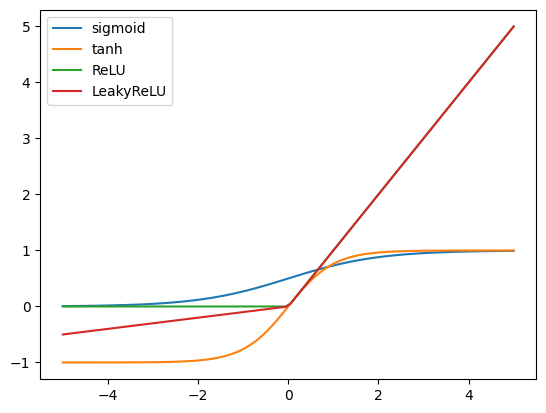

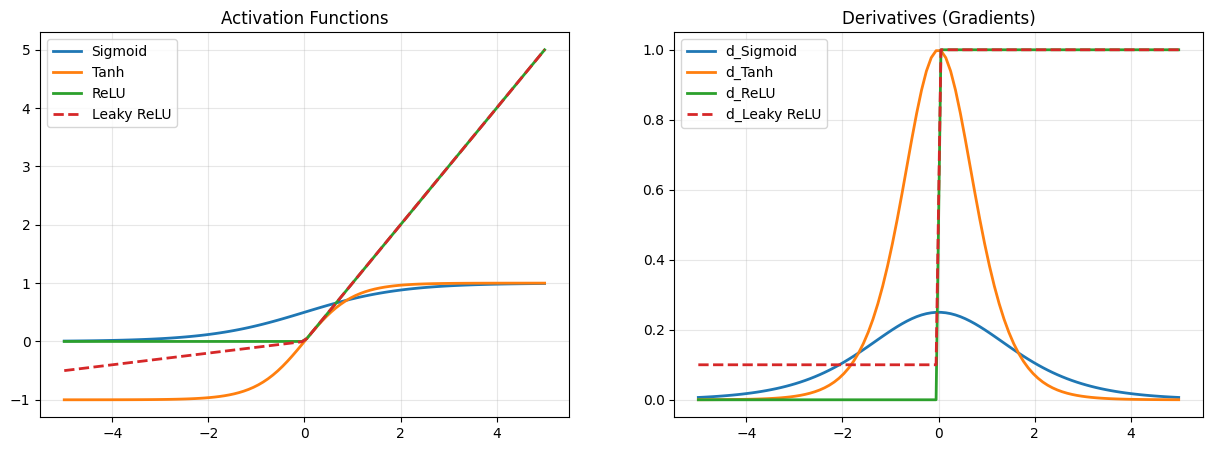

In [38]:
x = np.linspace(-5,5,100)
sig = sigmoid(x)
tan = tanh(x)
relu_vals = relu(x)
leaky_relu = np.where(x>0,x,0.1*x)
plt.plot(x,sig,label='sigmoid'); plt.plot(x,tan,label='tanh'); plt.plot(x,relu_vals,label='ReLU'); plt.plot(x,leaky_relu,label='LeakyReLU'); plt.legend();

# Continue with your implementation here
# 1. Define Derivatives
def d_sigmoid(x):
    s = sigmoid(x)
    return s * (1 - s)

def d_tanh(x):
    return 1 - np.tanh(x)**2

def d_relu(x):
    return np.where(x > 0, 1, 0)

def d_leaky_relu(x):
    return np.where(x > 0, 1, 0.1)

# Create Comparison Plots
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Plot Functions
ax[0].plot(x, sig, label='Sigmoid', lw=2)
ax[0].plot(x, tan, label='Tanh', lw=2)
ax[0].plot(x, relu_vals, label='ReLU', lw=2)
ax[0].plot(x, leaky_relu, label='Leaky ReLU', lw=2, linestyle='--')
ax[0].set_title("Activation Functions")
ax[0].grid(True, alpha=0.3)
ax[0].legend()

# Plot Derivatives
ax[1].plot(x, d_sigmoid(x), label='d_Sigmoid', lw=2)
ax[1].plot(x, d_tanh(x), label='d_Tanh', lw=2)
ax[1].plot(x, d_relu(x), label='d_ReLU', lw=2)
ax[1].plot(x, d_leaky_relu(x), label='d_Leaky ReLU', lw=2, linestyle='--')
ax[1].set_title("Derivatives (Gradients)")
ax[1].grid(True, alpha=0.3)
ax[1].legend()

plt.show()

Key Comparison Points
1. Vanishing Gradient: Sigmoid and Tanh derivatives peak at 0.25 and 1.0 respectively,
   but drop to zero for large inputs. This makes deep networks hard to train.
2. ReLU: Has a constant gradient of 1 for all positive inputs, solving vanishing gradients.
   However, it has a gradient of 0 for negative inputs ('Dying ReLU' problem).
3. Leaky ReLU: Fixes the 'Dying ReLU' problem by allowing a small, non-zero gradient (0.1)
   when the input is negative.

### Q14
Train MLP models of varying depth (2, 4, 8 layers) on synthetic 2D classification data. Compare decision boundaries and accuracies.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from keras import models, layers, Input
from keras.utils import to_categorical

# -------------------------------
# Generate synthetic 2D dataset
# -------------------------------
X, y = make_classification(
    n_samples=500, n_features=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.5, random_state=42
)

y_cat = to_categorical(y, 2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.3, random_state=42
)


# Continue with your implementation here
# Build the Model
model = models.Sequential([
    Input(shape=(2,)),                  # Input: 2 features
    layers.Dense(16, activation='relu'), # Hidden layer with 16 neurons
    layers.Dense(8, activation='relu'),  # Hidden layer with 8 neurons
    layers.Dense(2, activation='softmax') # Output: 2 classes
])

# Compile the Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the Model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.1,
    verbose=0
)

# Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy History
ax1.plot(history.history['accuracy'], label='train')
ax1.plot(history.history['val_accuracy'], label='val')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Plot Decision Boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
preds = model.predict(grid, verbose=0)
Z = np.argmax(preds, axis=1).reshape(xx.shape)

ax2.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
ax2.scatter(X_test[:, 0], X_test[:, 1], c=np.argmax(y_test, axis=1), edgecolors='k', cmap='RdBu')
ax2.set_title('Decision Boundary on Test Set')

plt.show()


Interpretation
- The model uses the 'Adam' optimizer, which adapts the learning rate for faster convergence.
- 'Categorical Crossentropy' is the standard loss for multi-class (or one-hot encoded binary) tasks.
- The decision boundary shows how the network has learned to separate the two classes in 2D space.

### Q15
Implement forward propagation for a 3-layer MLP with softmax output in NumPy. Test on sklearn digits dataset.

In [39]:
from sklearn.datasets import load_digits
digits = load_digits()
X_digits, y_digits = digits.data, digits.target

# Continue with your implementation here
# Preprocessing
# Scale data to [0, 1] for better stability and convert targets to one-hot
X_scaled = X_digits / 16.0
num_classes = 10
samples = X_scaled.shape[0]

# Initialize Weights and Biases
# Architecture: Input(64) -> Hidden1(32) -> Hidden2(16) -> Output(10)
np.random.seed(42)
W1 = np.random.randn(64, 32) * 0.1
b1 = np.zeros((1, 32))
W2 = np.random.randn(32, 16) * 0.1
b2 = np.zeros((1, 16))
W3 = np.random.randn(16, 10) * 0.1
b3 = np.zeros((1, 10))

# Activation Functions
def relu(x):
    return np.maximum(0, x)

def softmax(x):
    # Subtracting max(x) for numerical stability (prevents overflow)
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

# Forward Propagation Function
def forward_prop(X):
    # Layer 1
    z1 = np.dot(X, W1) + b1
    a1 = relu(z1)

    # Layer 2
    z2 = np.dot(a1, W2) + b2
    a2 = relu(z2)

    # Layer 3 (Output)
    z3 = np.dot(a2, W3) + b3
    a3 = softmax(z3)

    return a3

# Test the Forward Pass
probabilities = forward_prop(X_scaled)
predictions = np.argmax(probabilities, axis=1)

# Display results for the first 5 samples
import pandas as pd
results = pd.DataFrame({
    "Actual Digit": y_digits[:5],
    "Predicted (Untrained)": predictions[:5],
    "Max Probability": np.max(probabilities[:5], axis=1)
})

print("Forward Pass Results (Initial Untrained State):")
print(results)

Forward Pass Results (Initial Untrained State):
   Actual Digit  Predicted (Untrained)  Max Probability
0             0                      9         0.108044
1             1                      9         0.114886
2             2                      9         0.113143
3             3                      1         0.109045
4             4                      9         0.110809


### Q16
Train identical networks with different activations (ReLU vs tanh) on synthetic spiral data. Plot and compare decision boundaries.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras import models, layers, Input
from keras.utils import to_categorical

# -------------------------------
# Generate 2-class spiral dataset
# -------------------------------
def generate_spiral(n_points, noise=0.2):
    theta = np.sqrt(np.random.rand(n_points)) * 2 * np.pi  # random angles
    r_a = 2 * theta + np.pi
    x1 = np.cos(theta) * r_a + np.random.randn(n_points) * noise
    y1 = np.sin(theta) * r_a + np.random.randn(n_points) * noise

    x2 = -np.cos(theta) * r_a + np.random.randn(n_points) * noise
    y2 = -np.sin(theta) * r_a + np.random.randn(n_points) * noise

    X = np.vstack((np.append(x1, x2), np.append(y1, y2))).T
    y = np.hstack((np.zeros(n_points), np.ones(n_points)))
    return X, y

X, y = generate_spiral(500)
y_cat = to_categorical(y, 2)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.3, random_state=42)

# Continue with your implementation here
def build_model(activation_fn):
    model = models.Sequential([
        Input(shape=(2,)),
        layers.Dense(64, activation=activation_fn),
        layers.Dense(32, activation=activation_fn),
        layers.Dense(16, activation=activation_fn),
        layers.Dense(2, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Train ReLU Network
model_relu = build_model('relu')
history_relu = model_relu.fit(X_train, y_train, epochs=150, batch_size=32, verbose=0)

# Train Tanh Network
model_tanh = build_model('tanh')
history_tanh = model_tanh.fit(X_train, y_train, epochs=150, batch_size=32, verbose=0)

# Visualization
def plot_decision_boundary(model, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)
    Z = np.argmax(Z, axis=1).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k', cmap='RdBu')
    ax.set_title(title)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
plot_decision_boundary(model_relu, ax1, "ReLU Activation Boundary")
plot_decision_boundary(model_tanh, ax2, "Tanh Activation Boundary")
plt.show()

# Interpretation
print(f"ReLU Final Accuracy: {history_relu.history['accuracy'][-1]:.4f}")
print(f"Tanh Final Accuracy: {history_tanh.history['accuracy'][-1]:.4f}")

Observations
- ReLU boundaries tend to be more 'piecewise linear' and sharp.
- Tanh boundaries are usually smoother but can suffer from slower convergence in deeper networks due to the vanishing gradient problem.

### Q17
Use TensorFlow/Keras to train a simple MLP on sklearn digits dataset. Demonstrate both GradientTape and model.fit approaches.

In [40]:
import tensorflow as tf
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Continue with your implementation
# Prepare Data
digits = load_digits()
X = digits.data.astype(np.float32)
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features (MLPs are sensitive to scale)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the Model Architecture
def get_model():
    return tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(10) # Logits (raw scores)
    ])

# Approach A: High-Level model.fit
print("\n Training with model.fit")
model_fit = get_model()
model_fit.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)
model_fit.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
loss_a, acc_a = model_fit.evaluate(X_test, y_test, verbose=0)
print(f"model.fit Test Accuracy: {acc_a:.4f}")

# Approach B: Low-Level GradientTape
print("\nTraining with GradientTape")
model_tape = get_model()
optimizer = tf.keras.optimizers.Adam()
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# Create a simple data loader
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32)

for epoch in range(10):
    for step, (x_batch, y_batch) in enumerate(train_dataset):
        with tf.GradientTape() as tape:
            # Forward Pass
            logits = model_tape(x_batch, training=True)
            # Calculate Loss
            loss_value = loss_fn(y_batch, logits)

        # Compute Gradients
        grads = tape.gradient(loss_value, model_tape.trainable_weights)
        # Update Weights
        optimizer.apply_gradients(zip(grads, model_tape.trainable_weights))

# Evaluate GradientTape model
test_logits = model_tape(X_test, training=False)
test_acc = tf.keras.metrics.SparseCategoricalAccuracy()(y_test, test_logits)
print(f"GradientTape Test Accuracy: {test_acc.numpy():.4f}")


 Training with model.fit
model.fit Test Accuracy: 0.9472

Training with GradientTape
GradientTape Test Accuracy: 0.9583


### Q18
Generate a synthetic dataset and train a Keras MLP with mini-batch sizes 32, 128, 512. Compare convergence speed and stability.

Training with batch size: 32...
Training with batch size: 128...
Training with batch size: 512...


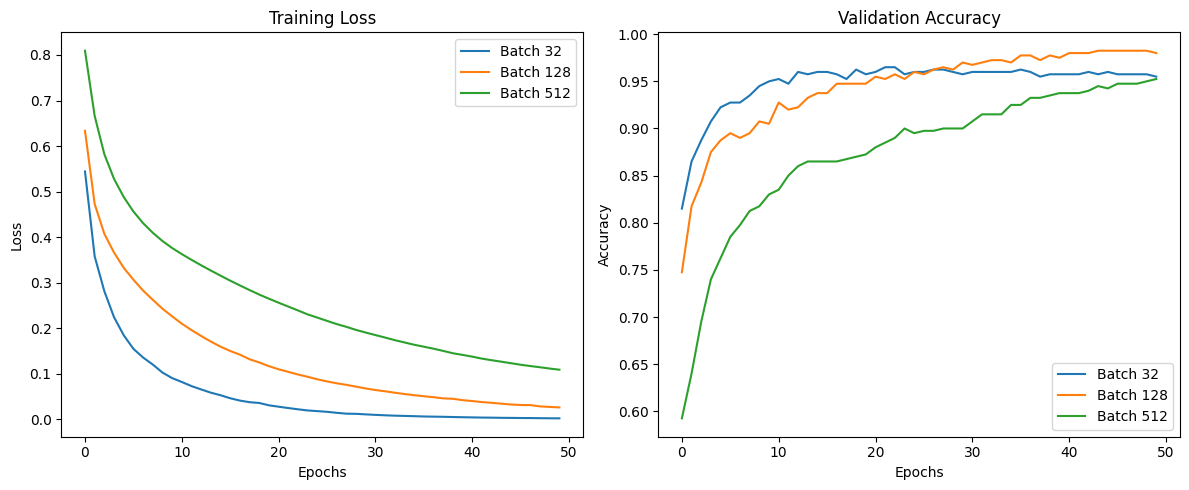

In [42]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from tensorflow.keras import models, layers, Input

X_syn, y_syn = make_classification(n_samples=2000, n_features=20, n_informative=15, random_state=42)

# Continue with your implementation
X_train, X_test, y_train, y_test = train_test_split(X_syn, y_syn, test_size=0.2, random_state=42)

def build_simple_mlp():
    model = models.Sequential([
        Input(shape=(20,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Train with different batch sizes
batch_sizes = [32, 128, 512]
histories = {}

for size in batch_sizes:
    print(f"Training with batch size: {size}...")
    model = build_simple_mlp()
    # Using the same number of epochs for direct comparison
    history = model.fit(X_train, y_train, epochs=50, batch_size=size, validation_data=(X_test, y_test), verbose=0)
    histories[size] = history

# Visualization
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
for size in batch_sizes:
    plt.plot(histories[size].history['loss'], label=f'Batch {size}')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
for size in batch_sizes:
    plt.plot(histories[size].history['val_accuracy'], label=f'Batch {size}')
plt.title('Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Comparison Analysis
- Batch Size 32: Faster convergence (more updates per epoch) but often more 'noisy' or 'jittery' curves.
- Batch Size 512: Very smooth curves and stable gradients, but requires more epochs to reach the same accuracy.
- Hardware Tip: Larger batch sizes utilize GPU parallelism better, but smaller batches often provide a 'regularization' effect that helps generalization.

### Q19
Train classifiers with two different losses: cross-entropy (classification) and MSE (regression). Compare learning curves.

In [ ]:
# classification: digits dataset, regression: california housing
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler

cal = fetch_california_housing()
X_cal, y_cal = cal.data, cal.target

# Continue with your implementation here
# Setup Data for Classification (Digits)
# (Re-using X_digits/y_digits from previous steps)
scaler_c = StandardScaler()
X_c = scaler_c.fit_transform(X_digits)
y_c = to_categorical(y_digits)

# Setup Data for Regression (California Housing)
scaler_r = StandardScaler()
X_r = scaler_r.fit_transform(X_cal)
y_r = y_cal # Targets are continuous values (house prices)

# Model A: Classification (Cross-Entropy)
model_ce = models.Sequential([
    Input(shape=(64,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model_ce.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Model B: Regression (MSE)
model_mse = models.Sequential([
    Input(shape=(8,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='linear') # No activation for regression output
])
model_mse.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train both
history_ce = model_ce.fit(X_c, y_c, epochs=50, batch_size=32, verbose=0, validation_split=0.2)
history_mse = model_mse.fit(X_r, y_r, epochs=50, batch_size=32, verbose=0, validation_split=0.2)

# Plotting the Learning Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Classification Curve
ax1.plot(history_ce.history['loss'], label='Train Loss (CE)')
ax1.plot(history_ce.history['val_loss'], label='Val Loss (CE)')
ax1.set_title('Cross-Entropy Learning Curve (Classification)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss Value')
ax1.legend()

# Regression Curve
ax2.plot(history_mse.history['loss'], label='Train Loss (MSE)')
ax2.plot(history_mse.history['val_loss'], label='Val Loss (MSE)')
ax2.set_title('MSE Learning Curve (Regression)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss Value')
ax2.legend()

plt.show()

Comparison Summary
- Cross-Entropy: Often drops sharply early on as the model quickly identifies simple class features.
- MSE: Can be sensitive to outliers and scale. Notice the loss units are 'squared prices',  making the curve scale very different from the probability-based CE loss.

### Q20
On MNIST dataset, train MLPs with optimizers (SGD, Momentum, RMSProp, Adam). Compare test accuracy and runtime. Summarize findings.

Training with SGD...
Training with Momentum...
Training with RMSProp...
Training with Adam...

Optimizer Performance Summary:
           Test Accuracy  Training Time (s)
Optimizer                                  
SGD               0.9371            41.3167
Momentum          0.9734            20.2977
RMSProp           0.9744            45.6734
Adam              0.9775            24.9570


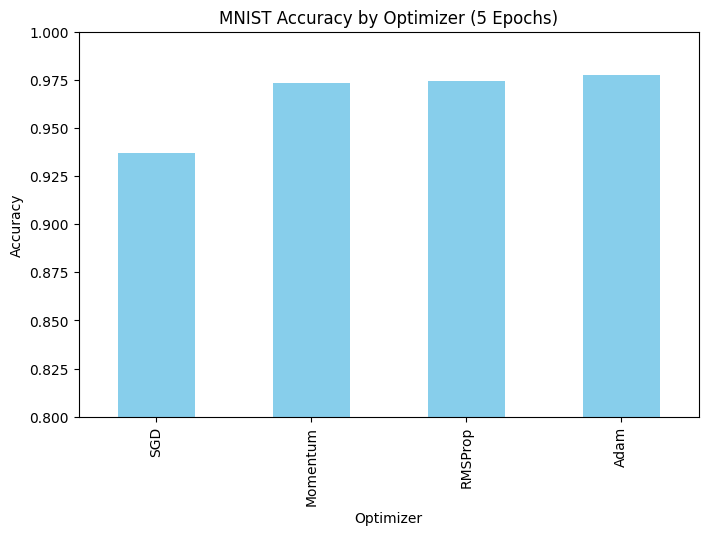

In [44]:
import time

mnist = tf.keras.datasets.mnist
(X_train_mnist, y_train_mnist), (X_test_mnist, y_test_mnist) = mnist.load_data()
X_train_mnist = X_train_mnist.reshape(-1,28*28)/255.0
X_test_mnist = X_test_mnist.reshape(-1,28*28)/255.0

# Continue with your implementation here
# Configuration
optimizers = {
    'SGD': tf.keras.optimizers.SGD(learning_rate=0.01),
    'Momentum': tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'RMSProp': tf.keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam': tf.keras.optimizers.Adam(learning_rate=0.001)
}

results = []

# Benchmark Loop
for name, opt in optimizers.items():
    print(f"Training with {name}...")

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(784,)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    start_time = time.time()
    history = model.fit(X_train_mnist, y_train_mnist, epochs=5, batch_size=64, verbose=0)
    end_time = time.time()

    test_loss, test_acc = model.evaluate(X_test_mnist, y_test_mnist, verbose=0)

    results.append({
        'Optimizer': name,
        'Test Accuracy': test_acc,
        'Training Time (s)': end_time - start_time
    })

# Summary Table
import pandas as pd
summary_df = pd.DataFrame(results).set_index('Optimizer')
print("\nOptimizer Performance Summary:")
print(summary_df.round(4))

# Visualization
summary_df['Test Accuracy'].plot(kind='bar', color='skyblue', figsize=(8, 5))
plt.title("MNIST Accuracy by Optimizer (5 Epochs)")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)
plt.show()

- Adam & RMSProp: The "smart" ones. They automatically speed up or slow down based on how the error is changing. This makes them the fastest to reach high accuracy.

- Momentum: The "heavy hitter." It builds up speed in the right direction, which helps it roll past small mistakes and stay on track better than plain SGD.

- SGD (Stochastic Gradient Descent): The "slow and steady" one. It’s the simplest method but often takes the longest to reach the same level of accuracy as the others.

- Conclusion: For most tasks like digit recognition, Adam is the best all-around choice because it is fast, stable, and requires the least amount of manual tuning.

### Q21
Train a deeper MLP on MNIST with dropout layers. Apply EarlyStopping and ReduceLROnPlateau callbacks. Plot training/validation curves.

In [46]:
# Continue with your implementation here
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks # <--- Add 'callbacks' here

# Build a Deeper Model with Dropout
model_deep = models.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_deep.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define Callbacks (Now 'callbacks' is defined!)
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

# Train
history = model_deep.fit(
    X_train_mnist, y_train_mnist,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9011 - loss: 0.3248 - val_accuracy: 0.9554 - val_loss: 0.1437 - learning_rate: 0.0010
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.9587 - loss: 0.1328 - val_accuracy: 0.9696 - val_loss: 0.0978 - learning_rate: 0.0010
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.9694 - loss: 0.0988 - val_accuracy: 0.9737 - val_loss: 0.0929 - learning_rate: 0.0010
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9760 - loss: 0.0764 - val_accuracy: 0.9737 - val_loss: 0.0907 - learning_rate: 0.0010
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9784 - loss: 0.0689 - val_accuracy: 0.9776 - val_loss: 0.0762 - learning_rate: 0.0010
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.9819 - loss: 0.0589 - val_accuracy: 0.9772 - val_loss: 0.0766 - learning_rate: 0.0010
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.9831 - loss

---